# Examen — Álgebra Lineal
### Bourbaki · Colegio de Matemáticas — Matemáticas Avanzadas para Ciencia de Datos

Este notebook resuelve los **3 ejercicios** del examen del módulo de Álgebra Lineal:

1. Multiplicación de matrices de tamaño arbitrario **sin NumPy**.
2. Resolución de un sistema de ecuaciones usando la **descomposición en valores singulares (SVD)**.
3. Comparación de **PCA vs SVD** sobre **MNIST** usando la **similitud coseno promedio** entre imágenes del mismo dígito.

---

## Ejercicio 1 — Multiplicación de matrices sin NumPy

Implementamos la multiplicación clásica $C = A B$ donde
$$C_{ij} = \sum_{k=1}^{n} A_{ik}\,B_{kj}.$$

La función acepta matrices de **tamaño arbitrario** (representadas como listas de listas) y valida que las dimensiones internas coincidan ($\text{cols}(A) = \text{filas}(B)$).

In [1]:
def multiplicar_matrices(A, B):
    """
    Multiplica dos matrices A (m x n) y B (n x p) sin usar NumPy.

    Parámetros
    ----------
    A : list[list[float]]  -- matriz de m filas y n columnas
    B : list[list[float]]  -- matriz de n filas y p columnas

    Devuelve
    --------
    list[list[float]]      -- matriz producto de m filas y p columnas

    Lanza
    -----
    ValueError si las dimensiones no son compatibles.
    """
    filas_A, cols_A = len(A), len(A[0])
    filas_B, cols_B = len(B), len(B[0])

    if cols_A != filas_B:
        raise ValueError(
            f"Dimensiones incompatibles: ({filas_A}x{cols_A}) x ({filas_B}x{cols_B}). "
            f"Se requiere que columnas de A ({cols_A}) == filas de B ({filas_B})."
        )

    # Matriz resultado inicializada en ceros (filas_A x cols_B)
    C = [[0 for _ in range(cols_B)] for _ in range(filas_A)]

    for i in range(filas_A):          # recorre filas de A
        for j in range(cols_B):       # recorre columnas de B
            acumulado = 0
            for k in range(cols_A):   # producto punto fila_i . columna_j
                acumulado += A[i][k] * B[k][j]
            C[i][j] = acumulado

    return C

**Prueba 1:** matriz rectangular $2\times3$ por $3\times2$.

In [2]:
A = [[1, 2, 3],
     [4, 5, 6]]

B = [[7,  8],
     [9, 10],
     [11, 12]]

C = multiplicar_matrices(A, B)
print("A x B =")
for fila in C:
    print(fila)
# Esperado: [58, 64] y [139, 154]

A x B =
[58, 64]
[139, 154]


**Prueba 2:** verificación automática contra NumPy y manejo de error por dimensiones incompatibles.

In [3]:
import numpy as np

# Verificación numérica contra numpy (solo para validar; NO se usa en la función)
assert np.allclose(np.array(multiplicar_matrices(A, B)), np.array(A) @ np.array(B))
print("Coincide con numpy ✓")

# Verificación del manejo de dimensiones incompatibles
try:
    multiplicar_matrices([[1, 2]], [[1, 2]])   # (1x2) x (1x2) -> inválido
except ValueError as e:
    print("Error capturado correctamente:", e)

# Prueba con matriz cuadrada (identidad)
I = [[1, 0], [0, 1]]
M = [[5, 6], [7, 8]]
print("M x I =", multiplicar_matrices(M, I))   # debe devolver M

Coincide con numpy ✓
Error capturado correctamente: Dimensiones incompatibles: (1x2) x (1x2). Se requiere que columnas de A (2) == filas de B (1).
M x I = [[5, 6], [7, 8]]


---
## Ejercicio 2 — Resolver un sistema de ecuaciones con SVD

Dado el sistema $A\mathbf{x} = \mathbf{b}$, usamos la descomposición
$$A = U\,\Sigma\,V^{T}.$$

La solución se obtiene con la **pseudoinversa**:
$$\mathbf{x} = V\,\Sigma^{+}\,U^{T}\,\mathbf{b},$$
donde $\Sigma^{+}$ se forma invirtiendo los valores singulares no nulos (los valores $\approx 0$ se dejan en cero por estabilidad numérica).

Resolvemos un sistema $3\times3$ representativo (puedes sustituirlo por el de la primera semana):

$$\begin{cases} 2x + y - z = 8 \\ -3x - y + 2z = -11 \\ -2x + y + 2z = -3 \end{cases}$$

In [4]:
import numpy as np

# Matriz de coeficientes y término independiente
A_sys = np.array([[ 2,  1, -1],
                  [-3, -1,  2],
                  [-2,  1,  2]], dtype=float)

b_sys = np.array([8, -11, -3], dtype=float)


def resolver_con_svd(A, b, tol=1e-12):
    """
    Resuelve A x = b mediante la descomposición en valores singulares.
    x = V * Sigma^+ * U^T * b
    """
    U, s, Vt = np.linalg.svd(A)

    # Pseudoinversa de los valores singulares: 1/s_i si s_i > tol, si no 0
    s_inv = np.array([1.0 / si if si > tol else 0.0 for si in s])

    x = Vt.T @ np.diag(s_inv) @ U.T @ b
    return x, s


x, s = resolver_con_svd(A_sys, b_sys)

print("Valores singulares:", s)
print("Solución x        :", x)               # Esperado: [2, 3, -1]
print("Verificación A@x  :", A_sys @ x)        # Esperado: [8, -11, -3]
print("Residual ||A@x-b||:", np.linalg.norm(A_sys @ x - b_sys))

assert np.allclose(A_sys @ x, b_sys), "La solución no satisface el sistema"
print("\nSistema resuelto correctamente ✓")

Valores singulares: [5.10343603 1.71519373 0.11424157]
Solución x        : [ 2.  3. -1.]
Verificación A@x  : [  8. -11.  -3.]
Residual ||A@x-b||: 1.988012357898529e-14

Sistema resuelto correctamente ✓


> **Nota.** Como $\Sigma^{+}$ es la pseudoinversa, este mismo método resuelve también sistemas **sobre/sub-determinados** (devolviendo la solución de mínimos cuadrados o de norma mínima), no solo sistemas cuadrados con solución única.

---
## Ejercicio 3 — PCA vs SVD en MNIST con similitud coseno promedio

**Objetivo:** reducir la dimensión de las imágenes de MNIST con dos métodos —**PCA** y **SVD**— y comparar, para cada dígito, la **similitud coseno promedio** entre las imágenes de ese mismo dígito en el espacio reducido.

**Diferencia conceptual clave:**
- **PCA** *centra* los datos (resta la media) antes de descomponer → captura la variación *entre* imágenes.
- **SVD** se aplica directamente sobre los datos *sin centrar* → conserva la componente del "promedio", por lo que la similitud coseno tiende a ser **más alta**.

In [5]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# 1. Cargar MNIST (784 = 28x28 pixeles)
print("Descargando MNIST (puede tardar un poco la primera vez)...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_full, y_full = mnist.data, mnist.target.astype(int)

# Submuestra aleatoria para que el notebook corra rápido
np.random.seed(0)
idx = np.random.choice(len(X_full), 5000, replace=False)
X = X_full[idx] / 255.0          # normalizar a [0, 1]
y = y_full[idx]

print("Forma de X:", X.shape)
print("Distribución de dígitos:", np.bincount(y))

Descargando MNIST (puede tardar un poco la primera vez)...
Forma de X: (5000, 784)
Distribución de dígitos: [501 573 494 494 475 424 472 549 504 514]


In [6]:
N_COMPONENTES = 50

# 2. Reducción con PCA (centra los datos internamente)
pca = PCA(n_components=N_COMPONENTES, random_state=0)
X_pca = pca.fit_transform(X)
print("PCA -> forma reducida:", X_pca.shape)

# 3. Reducción con SVD (sobre los datos SIN centrar)
#    X = U S V^T  ->  proyeccion = U[:, :k] * S[:k]
U, s, Vt = np.linalg.svd(X, full_matrices=False)
X_svd = U[:, :N_COMPONENTES] * s[:N_COMPONENTES]
print("SVD -> forma reducida:", X_svd.shape)

PCA -> forma reducida: (5000, 50)
SVD -> forma reducida: (5000, 50)


In [7]:
def coseno_promedio_por_digito(X_red, y):
    """
    Para cada dígito 0..9, calcula la similitud coseno promedio
    entre todos los pares (distintos) de imágenes de ese dígito.
    """
    resultados = {}
    for d in range(10):
        Xd = X_red[y == d]
        sim = cosine_similarity(Xd)            # matriz n x n de cosenos
        n = len(Xd)
        triu = np.triu_indices(n, k=1)         # pares (i<j), sin diagonal
        resultados[d] = sim[triu].mean()
    return resultados


cos_pca = coseno_promedio_por_digito(X_pca, y)
cos_svd = coseno_promedio_por_digito(X_svd, y)

# 4. Tabla comparativa
print(f"{'Dígito':>7} | {'PCA':>8} | {'SVD':>8}")
print("-" * 30)
for d in range(10):
    print(f"{d:>7} | {cos_pca[d]:>8.4f} | {cos_svd[d]:>8.4f}")

prom_pca = np.mean(list(cos_pca.values()))
prom_svd = np.mean(list(cos_svd.values()))
print("-" * 30)
print(f"{'PROM':>7} | {prom_pca:>8.4f} | {prom_svd:>8.4f}")

 Dígito |      PCA |      SVD
------------------------------
      0 |   0.3361 |   0.6261
      1 |   0.4853 |   0.6341
      2 |   0.1944 |   0.5744
      3 |   0.2031 |   0.5844
      4 |   0.2118 |   0.5566
      5 |   0.1111 |   0.5019
      6 |   0.2700 |   0.6163
      7 |   0.2796 |   0.5781
      8 |   0.1515 |   0.6232
      9 |   0.1953 |   0.5958
------------------------------
   PROM |   0.2438 |   0.5891


**Visualización** de la comparación por dígito.

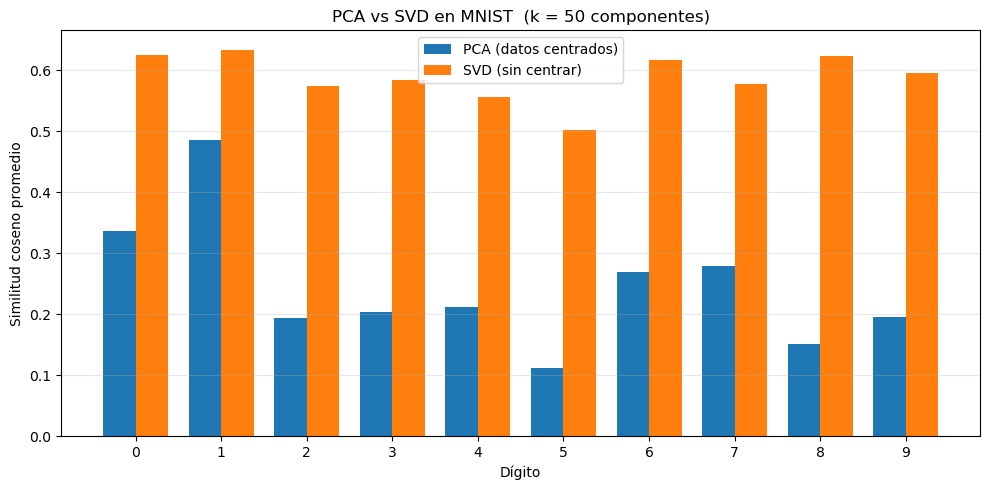

In [8]:
import matplotlib.pyplot as plt

digitos = list(range(10))
vals_pca = [cos_pca[d] for d in digitos]
vals_svd = [cos_svd[d] for d in digitos]

x_pos = np.arange(10)
ancho = 0.38

plt.figure(figsize=(10, 5))
plt.bar(x_pos - ancho/2, vals_pca, ancho, label='PCA (datos centrados)')
plt.bar(x_pos + ancho/2, vals_svd, ancho, label='SVD (sin centrar)')
plt.xticks(x_pos, digitos)
plt.xlabel('Dígito')
plt.ylabel('Similitud coseno promedio')
plt.title(f'PCA vs SVD en MNIST  (k = {N_COMPONENTES} componentes)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusiones

- Con **SVD sin centrar**, la similitud coseno promedio es **sistemáticamente más alta**, porque todos los vectores comparten la componente del promedio (las imágenes de MNIST son mayoritariamente fondo oscuro con trazo claro, así que apuntan en una dirección común).
- Con **PCA**, al haber restado la media, se elimina esa componente compartida y los cosenos reflejan la similitud de la *variación* respecto al dígito promedio; por eso son menores y discriminan mejor entre dígitos.
- Ambos métodos están relacionados: **PCA equivale a aplicar SVD a la matriz de datos centrada**. La diferencia observada en la métrica se debe únicamente a ese centrado.